<a href="https://colab.research.google.com/github/Jyoshna0408/Real-Estate-Investment-Analytics/blob/main/Real_Estate_Investment_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Real Estate Price & Investment Analytics**

**1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

**2: Upload Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Real estate.csv to Real estate (1).csv


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


**3: Rename Columns**

In [3]:
df.columns = [
    "id",
    "transaction_date",
    "house_age",
    "distance_to_mrt",
    "num_stores",
    "latitude",
    "longitude",
    "price"
]

**4: Basic Cleaning**

In [4]:
df = df.drop_duplicates()
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                414 non-null    int64  
 1   transaction_date  414 non-null    float64
 2   house_age         414 non-null    float64
 3   distance_to_mrt   414 non-null    float64
 4   num_stores        414 non-null    int64  
 5   latitude          414 non-null    float64
 6   longitude         414 non-null    float64
 7   price             414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


**5: Exploratory Data Analysis**

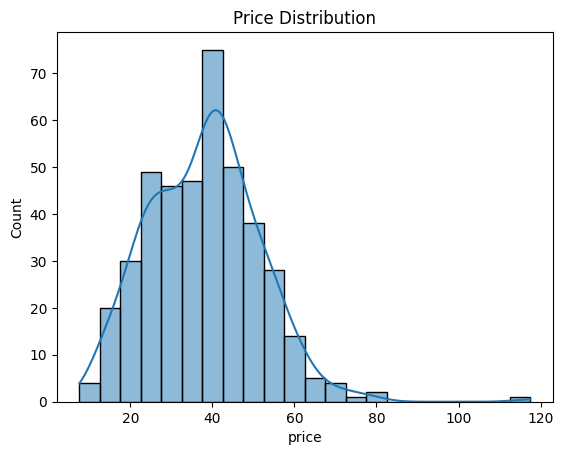

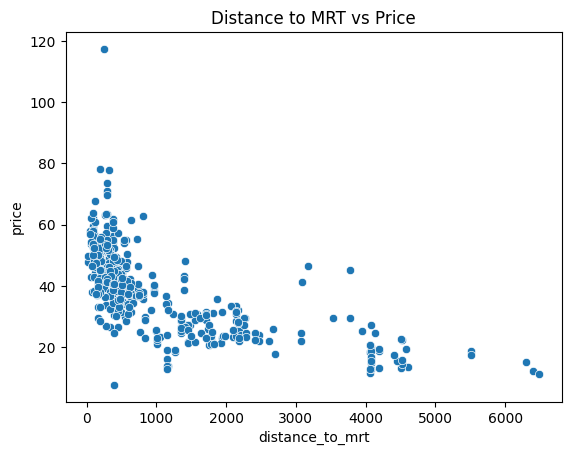

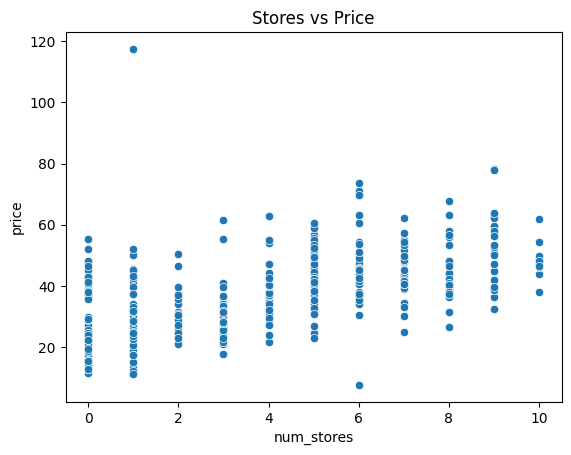

In [5]:
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

sns.scatterplot(x='distance_to_mrt', y='price', data=df)
plt.title("Distance to MRT vs Price")
plt.show()

sns.scatterplot(x='num_stores', y='price', data=df)
plt.title("Stores vs Price")
plt.show()

**6: Feature Engineering**

In [6]:
df['price_per_unit'] = df['price']
df['location_score'] = df['num_stores'] / (df['distance_to_mrt'] + 1)
df['property_age'] = df['house_age']

**7: Select Features**

In [7]:
X = df[[
    'house_age',
    'distance_to_mrt',
    'num_stores',
    'latitude',
    'longitude',
    'location_score'
]]

y = df['price']

**8: Train-Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**9: Train Model**

In [9]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

**10: Predictions**

In [10]:
predictions = model.predict(X_test)

**11: Evaluation**

In [11]:
print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.7953085863088128
MAE: 4.209022972843766


**12: Feature Importance**

In [12]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

           Feature  Importance
1  distance_to_mrt    0.557003
0        house_age    0.181363
3         latitude    0.119496
4        longitude    0.071092
5   location_score    0.051337
2       num_stores    0.019710


**13: ROI Calculation**

In [13]:
df['roi'] = (df['price'] - df['price'].mean()) / df['price'].mean()

**14: Add Predictions to Full Data**

In [14]:
df['predicted_price'] = model.predict(X)

**15: Final Dataset for Power BI**

In [15]:
df.to_csv("real_estate_final.csv", index=False)

**16: Download File**

In [16]:
files.download("real_estate_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>